In [0]:
customers_df = spark.read.csv(
    "/Volumes/shashank_databricks123/default/retail/customers.csv",
    header=True,
    inferSchema=True
)
print("Customers Schema")
customers_df.printSchema()
customers_df.show()

Customers Schema
root
 |-- customer_id: string (nullable = true)
 |-- customer_name: string (nullable = true)
 |-- city: string (nullable = true)
 |-- state: string (nullable = true)
 |-- customer_type: string (nullable = true)

+-----------+-------------+---------+-----------+-------------+
|customer_id|customer_name|     city|      state|customer_type|
+-----------+-------------+---------+-----------+-------------+
|       C101| Rahul Sharma|Hyderabad|  Telangana|      Premium|
|       C102|  Priya Reddy|Bangalore|  Karnataka|      Regular|
|       C103|   Amit Kumar|   Mumbai|Maharashtra|      Regular|
|       C104|  Sneha Patel|    Delhi|      Delhi|      Premium|
|       C105|   Farhan Ali|  Chennai| Tamil Nadu|      Regular|
|       C106|   Neha Singh|     Pune|Maharashtra|      Premium|
|       C107|  Arjun Verma|Hyderabad|  Telangana|      Regular|
|       C108|   Meera Nair|    Kochi|     Kerala|      Premium|
+-----------+-------------+---------+-----------+-------------+



In [0]:
products_df = spark.read.csv(
    "/Volumes/shashank_databricks123/default/retail/products.csv",
    header=True,
    inferSchema=True
)
print("Products Schema")
products_df.printSchema()
products_df.show()

Products Schema
root
 |-- product_id: string (nullable = true)
 |-- product_name: string (nullable = true)
 |-- category: string (nullable = true)
 |-- unit_price: integer (nullable = true)

+----------+------------+-----------+----------+
|product_id|product_name|   category|unit_price|
+----------+------------+-----------+----------+
|      P101|      Laptop|Electronics|     65000|
|      P102|      Mobile|Electronics|     25000|
|      P103|       Chair|  Furniture|      7000|
|      P104|       Table|  Furniture|     12000|
|      P105|       Shoes|    Fashion|      4500|
|      P106|       Watch|    Fashion|      8000|
|      P107|          TV|Electronics|     45000|
|      P108|         Bag|    Fashion|      3000|
+----------+------------+-----------+----------+



In [0]:
orders_df = spark.read.csv(
    "/Volumes/shashank_databricks123/default/retail/orders.csv",
    header=True,
    inferSchema=True
)
print("Orders Schema")
orders_df.printSchema()
orders_df.show()

Orders Schema
root
 |-- order_id: string (nullable = true)
 |-- customer_id: string (nullable = true)
 |-- product_id: string (nullable = true)
 |-- order_date: date (nullable = true)
 |-- quantity: integer (nullable = true)
 |-- status: string (nullable = true)

+--------+-----------+----------+----------+--------+---------+
|order_id|customer_id|product_id|order_date|quantity|   status|
+--------+-----------+----------+----------+--------+---------+
|   O1001|       C101|      P101|2026-06-01|       1|Completed|
|   O1002|       C102|      P102|2026-06-01|       2|Completed|
|   O1003|       C103|      P103|2026-06-02|       3|  Pending|
|   O1004|       C104|      P104|2026-06-02|       2|Completed|
|   O1005|       C105|      P105|2026-06-03|       4|Cancelled|
|   O1006|       C106|      P106|2026-06-03|       1|Completed|
|   O1007|       C107|      P107|2026-06-04|       1|Completed|
|   O1008|       C108|      P108|2026-06-04|       5|Completed|
|   O1009|       C101|      P102

In [0]:
preferences_raw_df = spark.read.option("multiline", "true").json(
    "/Volumes/shashank_databricks123/default/retail/customer_preferences.json"
)
print("Customer Preferences Schema")
preferences_raw_df.printSchema()
preferences_raw_df.show()

Customer Preferences Schema
root
 |-- customer_id: string (nullable = true)
 |-- loyalty: struct (nullable = true)
 |    |-- points: long (nullable = true)
 |    |-- tier: string (nullable = true)
 |-- preferred_channel: string (nullable = true)

+-----------+----------------+-----------------+
|customer_id|         loyalty|preferred_channel|
+-----------+----------------+-----------------+
|       C101|    {1200, Gold}|           Online|
|       C102|   {700, Silver}|            Store|
|       C104|{2200, Platinum}|           Online|
|       C108|    {1500, Gold}|       Mobile App|
+-----------+----------------+-----------------+



In [0]:
customers_df.write.format("delta").mode("overwrite").saveAsTable("bronze_customers")
products_df.write.format("delta").mode("overwrite").saveAsTable("bronze_products")
orders_df.write.format("delta").mode("overwrite").saveAsTable("bronze_orders")
preferences_raw_df.write.format("delta").mode("overwrite").saveAsTable("bronze_customer_preferences")
print("All Bronze Delta tables saved successfully.")

All Bronze Delta tables saved successfully.


In [0]:
 
from pyspark.sql.functions import (
    col, when, to_date, date_format
)

In [0]:
customers_clean_df = customers_df \
    .fillna({"city": "Unknown", "state": "Unknown", "customer_type": "Regular"}) \
    .dropna(subset=["customer_id"])

In [0]:
products_clean_df = products_df \
    .fillna({"category": "General", "unit_price": 0}) \
    .dropna(subset=["product_id"])

In [0]:
orders_clean_df = orders_df \
    .fillna({"status": "Unknown", "quantity": 0}) \
    .dropna(subset=["order_id"])

In [0]:
print("Null values handled.")
customers_clean_df.show()

Null values handled.
+-----------+-------------+---------+-----------+-------------+
|customer_id|customer_name|     city|      state|customer_type|
+-----------+-------------+---------+-----------+-------------+
|       C101| Rahul Sharma|Hyderabad|  Telangana|      Premium|
|       C102|  Priya Reddy|Bangalore|  Karnataka|      Regular|
|       C103|   Amit Kumar|   Mumbai|Maharashtra|      Regular|
|       C104|  Sneha Patel|    Delhi|      Delhi|      Premium|
|       C105|   Farhan Ali|  Chennai| Tamil Nadu|      Regular|
|       C106|   Neha Singh|     Pune|Maharashtra|      Premium|
|       C107|  Arjun Verma|Hyderabad|  Telangana|      Regular|
|       C108|   Meera Nair|    Kochi|     Kerala|      Premium|
+-----------+-------------+---------+-----------+-------------+



In [0]:
preferences_flat_df = preferences_raw_df.select(
    col("customer_id"),
    col("preferred_channel"),
    col("loyalty.tier").alias("loyalty_tier"),
    col("loyalty.points").alias("loyalty_points")
)
print("Flattened Preferences")
preferences_flat_df.show()

Flattened Preferences
+-----------+-----------------+------------+--------------+
|customer_id|preferred_channel|loyalty_tier|loyalty_points|
+-----------+-----------------+------------+--------------+
|       C101|           Online|        Gold|          1200|
|       C102|            Store|      Silver|           700|
|       C104|           Online|    Platinum|          2200|
|       C108|       Mobile App|        Gold|          1500|
+-----------+-----------------+------------+--------------+



In [0]:
customers_with_prefs_df = customers_clean_df.join(
    preferences_flat_df, on="customer_id", how="left"
)
print("Customers with Preferences")
customers_with_prefs_df.show()

Customers with Preferences
+-----------+-------------+---------+-----------+-------------+-----------------+------------+--------------+
|customer_id|customer_name|     city|      state|customer_type|preferred_channel|loyalty_tier|loyalty_points|
+-----------+-------------+---------+-----------+-------------+-----------------+------------+--------------+
|       C101| Rahul Sharma|Hyderabad|  Telangana|      Premium|           Online|        Gold|          1200|
|       C102|  Priya Reddy|Bangalore|  Karnataka|      Regular|            Store|      Silver|           700|
|       C103|   Amit Kumar|   Mumbai|Maharashtra|      Regular|             NULL|        NULL|          NULL|
|       C104|  Sneha Patel|    Delhi|      Delhi|      Premium|           Online|    Platinum|          2200|
|       C105|   Farhan Ali|  Chennai| Tamil Nadu|      Regular|             NULL|        NULL|          NULL|
|       C106|   Neha Singh|     Pune|Maharashtra|      Premium|             NULL|        NULL

In [0]:
orders_customers_df = orders_clean_df.join(
    customers_clean_df, on="customer_id", how="left"
)
print("Orders joined with Customers")
orders_customers_df.show()

Orders joined with Customers
+-----------+--------+----------+----------+--------+---------+-------------+---------+-----------+-------------+
|customer_id|order_id|product_id|order_date|quantity|   status|customer_name|     city|      state|customer_type|
+-----------+--------+----------+----------+--------+---------+-------------+---------+-----------+-------------+
|       C101|   O1001|      P101|2026-06-01|       1|Completed| Rahul Sharma|Hyderabad|  Telangana|      Premium|
|       C102|   O1002|      P102|2026-06-01|       2|Completed|  Priya Reddy|Bangalore|  Karnataka|      Regular|
|       C103|   O1003|      P103|2026-06-02|       3|  Pending|   Amit Kumar|   Mumbai|Maharashtra|      Regular|
|       C104|   O1004|      P104|2026-06-02|       2|Completed|  Sneha Patel|    Delhi|      Delhi|      Premium|
|       C105|   O1005|      P105|2026-06-03|       4|Cancelled|   Farhan Ali|  Chennai| Tamil Nadu|      Regular|
|       C106|   O1006|      P106|2026-06-03|       1|Comple

In [0]:
products_renamed_df = products_clean_df \
    .withColumnRenamed("unit_price", "product_unit_price")
 
orders_full_df = orders_customers_df.join(
    products_renamed_df, on="product_id", how="left"
)
print("Orders joined with Customers and Products")
orders_full_df.show()

Orders joined with Customers and Products
+----------+-----------+--------+----------+--------+---------+-------------+---------+-----------+-------------+------------+-----------+------------------+
|product_id|customer_id|order_id|order_date|quantity|   status|customer_name|     city|      state|customer_type|product_name|   category|product_unit_price|
+----------+-----------+--------+----------+--------+---------+-------------+---------+-----------+-------------+------------+-----------+------------------+
|      P101|       C101|   O1001|2026-06-01|       1|Completed| Rahul Sharma|Hyderabad|  Telangana|      Premium|      Laptop|Electronics|             65000|
|      P102|       C102|   O1002|2026-06-01|       2|Completed|  Priya Reddy|Bangalore|  Karnataka|      Regular|      Mobile|Electronics|             25000|
|      P103|       C103|   O1003|2026-06-02|       3|  Pending|   Amit Kumar|   Mumbai|Maharashtra|      Regular|       Chair|  Furniture|              7000|
|      P10

In [0]:
orders_transformed_df = orders_full_df \
    .withColumn("revenue", col("quantity") * col("product_unit_price")) \
    .withColumn("order_date", to_date(col("order_date"), "yyyy-MM-dd")) \
    .withColumn("order_month", date_format(col("order_date"), "MMMM yyyy")) \
    .withColumn(
        "customer_segment",
        when(col("customer_type") == "Premium", "High Value")
        .otherwise("Standard Value")
    )
 
print("Transformed Orders")
orders_transformed_df.select(
    "order_id", "customer_name", "product_name", "category",
    "quantity", "product_unit_price", "revenue",
    "order_month", "customer_type", "customer_segment", "status"
).show()

Transformed Orders
+--------+-------------+------------+-----------+--------+------------------+-------+-----------+-------------+----------------+---------+
|order_id|customer_name|product_name|   category|quantity|product_unit_price|revenue|order_month|customer_type|customer_segment|   status|
+--------+-------------+------------+-----------+--------+------------------+-------+-----------+-------------+----------------+---------+
|   O1001| Rahul Sharma|      Laptop|Electronics|       1|             65000|  65000|  June 2026|      Premium|      High Value|Completed|
|   O1002|  Priya Reddy|      Mobile|Electronics|       2|             25000|  50000|  June 2026|      Regular|  Standard Value|Completed|
|   O1003|   Amit Kumar|       Chair|  Furniture|       3|              7000|  21000|  June 2026|      Regular|  Standard Value|  Pending|
|   O1004|  Sneha Patel|       Table|  Furniture|       2|             12000|  24000|  June 2026|      Premium|      High Value|Completed|
|   O100

In [0]:
orders_transformed_df.write.format("delta").mode("overwrite").saveAsTable("silver_orders")
customers_with_prefs_df.write.format("delta").mode("overwrite").saveAsTable("silver_customers")
products_clean_df.write.format("delta").mode("overwrite").saveAsTable("silver_products")
print("All Silver Delta tables saved successfully.")

All Silver Delta tables saved successfully.


In [0]:
orders_transformed_df.createOrReplaceTempView("orders_view")
customers_with_prefs_df.createOrReplaceTempView("customers_view")
products_clean_df.createOrReplaceTempView("products_view")
print("Temporary views created: orders_view, customers_view, products_view")

Temporary views created: orders_view, customers_view, products_view


In [0]:
total_revenue_df = spark.sql("""
    SELECT
        SUM(revenue) AS total_revenue
    FROM orders_view
    WHERE status = 'Completed'
""")
print("Total Revenue")
total_revenue_df.show()

Total Revenue
+-------------+
|total_revenue|
+-------------+
|       297000|
+-------------+



In [0]:
revenue_by_city_df = spark.sql("""
    SELECT
        city,
        SUM(revenue) AS total_revenue,
        COUNT(order_id) AS total_orders
    FROM orders_view
    WHERE status = 'Completed'
    GROUP BY city
    ORDER BY total_revenue DESC
""")
print("Revenue by City")
revenue_by_city_df.show()

Revenue by City
+---------+-------------+------------+
|     city|total_revenue|total_orders|
+---------+-------------+------------+
|Hyderabad|       135000|           3|
|    Delhi|        89000|           2|
|Bangalore|        50000|           1|
|    Kochi|        15000|           1|
|     Pune|         8000|           1|
+---------+-------------+------------+



In [0]:
revenue_by_category_df = spark.sql("""
    SELECT
        category,
        SUM(revenue) AS total_revenue,
        COUNT(order_id) AS total_orders
    FROM orders_view
    WHERE status = 'Completed'
    GROUP BY category
    ORDER BY total_revenue DESC
""")
print("Revenue by Category")
revenue_by_category_df.show()

Revenue by Category
+-----------+-------------+------------+
|   category|total_revenue|total_orders|
+-----------+-------------+------------+
|Electronics|       250000|           5|
|  Furniture|        24000|           1|
|    Fashion|        23000|           2|
+-----------+-------------+------------+



In [0]:
top_customers_df = spark.sql("""
    SELECT
        customer_id,
        customer_name,
        SUM(revenue) AS total_revenue,
        COUNT(order_id) AS total_orders
    FROM orders_view
    GROUP BY customer_id, customer_name
    ORDER BY total_revenue DESC
""")
print("Top Customers by Revenue")
top_customers_df.show()

Top Customers by Revenue
+-----------+-------------+-------------+------------+
|customer_id|customer_name|total_revenue|total_orders|
+-----------+-------------+-------------+------------+
|       C101| Rahul Sharma|        90000|           2|
|       C104|  Sneha Patel|        89000|           2|
|       C102|  Priya Reddy|        50000|           1|
|       C107|  Arjun Verma|        45000|           1|
|       C103|   Amit Kumar|        21000|           1|
|       C105|   Farhan Ali|        18000|           1|
|       C108|   Meera Nair|        15000|           1|
|       C106|   Neha Singh|         8000|           1|
+-----------+-------------+-------------+------------+



In [0]:
completed_orders_df = spark.sql("""
    SELECT
        order_id, customer_name, product_name, category,
        order_date, quantity, product_unit_price, revenue, status
    FROM orders_view
    WHERE status = 'Completed'
    ORDER BY order_date
""")
print("Completed Orders")
completed_orders_df.show()

Completed Orders
+--------+-------------+------------+-----------+----------+--------+------------------+-------+---------+
|order_id|customer_name|product_name|   category|order_date|quantity|product_unit_price|revenue|   status|
+--------+-------------+------------+-----------+----------+--------+------------------+-------+---------+
|   O1001| Rahul Sharma|      Laptop|Electronics|2026-06-01|       1|             65000|  65000|Completed|
|   O1002|  Priya Reddy|      Mobile|Electronics|2026-06-01|       2|             25000|  50000|Completed|
|   O1004|  Sneha Patel|       Table|  Furniture|2026-06-02|       2|             12000|  24000|Completed|
|   O1006|   Neha Singh|       Watch|    Fashion|2026-06-03|       1|              8000|   8000|Completed|
|   O1007|  Arjun Verma|          TV|Electronics|2026-06-04|       1|             45000|  45000|Completed|
|   O1008|   Meera Nair|         Bag|    Fashion|2026-06-04|       5|              3000|  15000|Completed|
|   O1009| Rahul Sha

In [0]:
from pyspark.sql.functions import rank, row_number, sum as spark_sum
from pyspark.sql.window import Window

In [0]:
import warnings
warnings.filterwarnings("ignore")

In [0]:
product_revenue_df = orders_transformed_df.groupBy("product_id", "product_name", "category") \
    .agg(spark_sum("revenue").alias("total_revenue"))
product_window = Window.orderBy(col("total_revenue").desc())
ranked_products_df = product_revenue_df.withColumn(
    "revenue_rank", rank().over(product_window)
)
print("Products Ranked by Revenue")
ranked_products_df.show()

Products Ranked by Revenue
+----------+------------+-----------+-------------+------------+
|product_id|product_name|   category|total_revenue|revenue_rank|
+----------+------------+-----------+-------------+------------+
|      P101|      Laptop|Electronics|       130000|           1|
|      P102|      Mobile|Electronics|        75000|           2|
|      P107|          TV|Electronics|        45000|           3|
|      P104|       Table|  Furniture|        24000|           4|
|      P103|       Chair|  Furniture|        21000|           5|
|      P105|       Shoes|    Fashion|        18000|           6|
|      P108|         Bag|    Fashion|        15000|           7|
|      P106|       Watch|    Fashion|         8000|           8|
+----------+------------+-----------+-------------+------------+



In [0]:
customer_revenue_df = orders_transformed_df.groupBy("customer_id", "customer_name") \
    .agg(spark_sum("revenue").alias("total_revenue"))
customer_window = Window.orderBy(col("total_revenue").desc())
ranked_customers_df = customer_revenue_df.withColumn(
    "revenue_rank", rank().over(customer_window)
)
print("Customers Ranked by Revenue")
ranked_customers_df.show()

Customers Ranked by Revenue
+-----------+-------------+-------------+------------+
|customer_id|customer_name|total_revenue|revenue_rank|
+-----------+-------------+-------------+------------+
|       C101| Rahul Sharma|        90000|           1|
|       C104|  Sneha Patel|        89000|           2|
|       C102|  Priya Reddy|        50000|           3|
|       C107|  Arjun Verma|        45000|           4|
|       C103|   Amit Kumar|        21000|           5|
|       C105|   Farhan Ali|        18000|           6|
|       C108|   Meera Nair|        15000|           7|
|       C106|   Neha Singh|         8000|           8|
+-----------+-------------+-------------+------------+



In [0]:
top3_customers_df = ranked_customers_df.filter(col("revenue_rank") <= 3)
print("Top 3 Customers by Revenue")
top3_customers_df.show()

Top 3 Customers by Revenue
+-----------+-------------+-------------+------------+
|customer_id|customer_name|total_revenue|revenue_rank|
+-----------+-------------+-------------+------------+
|       C101| Rahul Sharma|        90000|           1|
|       C104|  Sneha Patel|        89000|           2|
|       C102|  Priya Reddy|        50000|           3|
+-----------+-------------+-------------+------------+



In [0]:
category_product_window = Window.partitionBy("category").orderBy(col("total_revenue").desc())
top_product_per_category_df = product_revenue_df \
    .withColumn("rank_in_category", row_number().over(category_product_window)) \
    .filter(col("rank_in_category") == 1) \
    .drop("rank_in_category")
print("Top Product in Each Category")
top_product_per_category_df.show()

Top Product in Each Category
+----------+------------+-----------+-------------+
|product_id|product_name|   category|total_revenue|
+----------+------------+-----------+-------------+
|      P101|      Laptop|Electronics|       130000|
|      P105|       Shoes|    Fashion|        18000|
|      P104|       Table|  Furniture|        24000|
+----------+------------+-----------+-------------+



In [0]:
daily_revenue_df = orders_transformed_df.groupBy("order_date") \
    .agg(spark_sum("revenue").alias("daily_revenue")) \
    .orderBy("order_date")
running_window = Window.orderBy("order_date").rowsBetween(Window.unboundedPreceding, Window.currentRow)
running_revenue_df = daily_revenue_df.withColumn(
    "running_total_revenue", spark_sum("daily_revenue").over(running_window)
)
print("Running Revenue by Date")
running_revenue_df.show()

Running Revenue by Date
+----------+-------------+---------------------+
|order_date|daily_revenue|running_total_revenue|
+----------+-------------+---------------------+
|2026-06-01|       115000|               115000|
|2026-06-02|        45000|               160000|
|2026-06-03|        26000|               186000|
|2026-06-04|        60000|               246000|
|2026-06-05|        90000|               336000|
+----------+-------------+---------------------+



In [0]:
orders_transformed_df.write \
    .format("delta") \
    .mode("overwrite") \
    .save("/Volumes/shashank_databricks123/default/retail/orders_delta")

In [0]:
orders_transformed_df.write \
    .format("delta") \
    .mode("overwrite") \
    .saveAsTable("gold_orders")
 
print("Delta table created using saveAsTable: gold_orders")


Delta table created using saveAsTable: gold_orders


In [0]:
spark.sql("""
    CREATE TABLE IF NOT EXISTS gold_orders_sql
    USING DELTA
    AS
    SELECT * FROM silver_orders
""")
print("Delta table created using SQL: gold_orders_sql")


In [0]:
spark.sql("DESCRIBE HISTORY gold_orders").show(truncate=False)

+-------+-------------------+---------------+-------------------------------------------------------+---------------------------------+----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+----+------------------+------------------------------------+------------------------+-----------+-----------------+-------------+-------------------------------------------------------------------------------------------------------------------------------------------+------------+------------------------------------------+
|version|timestamp          |userId         |userName                                               |operation                        |operationParameters                                                                                                                                                             

In [0]:
old_version_df = spark.read.format("delta") \
    .option("versionAsOf", 0) \
    .table("gold_orders")
print("Time Travel: Version 0 of gold_orders")
old_version_df.show()

Time Travel: Version 0 of gold_orders
+----------+-----------+--------+----------+--------+---------+-------------+---------+-----------+-------------+------------+-----------+------------------+-------+-----------+----------------+
|product_id|customer_id|order_id|order_date|quantity|   status|customer_name|     city|      state|customer_type|product_name|   category|product_unit_price|revenue|order_month|customer_segment|
+----------+-----------+--------+----------+--------+---------+-------------+---------+-----------+-------------+------------+-----------+------------------+-------+-----------+----------------+
|      P101|       C101|   O1001|2026-06-01|       1|Completed| Rahul Sharma|Hyderabad|  Telangana|      Premium|      Laptop|Electronics|             65000|  65000|  June 2026|      High Value|
|      P102|       C102|   O1002|2026-06-01|       2|Completed|  Priya Reddy|Bangalore|  Karnataka|      Regular|      Mobile|Electronics|             25000|  50000|  June 2026|  Sta

In [0]:
from delta.tables import DeltaTable
from pyspark.sql.functions import lit
updated_customers_data = [
    ("C103", "Nagpur", "Maharashtra", "Premium"),
    ("C105", "Coimbatore", "Tamil Nadu", "Premium"),
    ("C109", "Surat", "Gujarat", "Regular")
]
updated_customers_df = spark.createDataFrame(
    updated_customers_data,
    ["customer_id", "city", "state", "customer_type"]
)
delta_table = DeltaTable.forName(spark, "silver_customers")
delta_table.alias("target").merge(
    updated_customers_df.alias("source"),
    "target.customer_id = source.customer_id"
).whenMatchedUpdate(set={
    "city":          "source.city",
    "state":         "source.state",
    "customer_type": "source.customer_type"
}).whenNotMatchedInsert(values={
    "customer_id":   "source.customer_id",
    "customer_name": lit('Unknown'),
    "city":          "source.city",
    "state":         "source.state",
    "customer_type": "source.customer_type"
}).execute()
print("SCD Type 1 Merge completed on silver_customers.")
spark.table("silver_customers").show()

SCD Type 1 Merge completed on silver_customers.
+-----------+-------------+----------+-----------+-------------+-----------------+------------+--------------+
|customer_id|customer_name|      city|      state|customer_type|preferred_channel|loyalty_tier|loyalty_points|
+-----------+-------------+----------+-----------+-------------+-----------------+------------+--------------+
|       C101| Rahul Sharma| Hyderabad|  Telangana|      Premium|           Online|        Gold|          1200|
|       C102|  Priya Reddy| Bangalore|  Karnataka|      Regular|            Store|      Silver|           700|
|       C104|  Sneha Patel|     Delhi|      Delhi|      Premium|           Online|    Platinum|          2200|
|       C106|   Neha Singh|      Pune|Maharashtra|      Premium|             NULL|        NULL|          NULL|
|       C107|  Arjun Verma| Hyderabad|  Telangana|      Regular|             NULL|        NULL|          NULL|
|       C108|   Meera Nair|     Kochi|     Kerala|      Premium|

In [0]:
spark.sql("DESCRIBE HISTORY silver_customers").show(5, truncate=False)

+-------+-------------------+---------------+-------------------------------------------------------+---------------------------------+----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+----+------------------+------------------------------------+------------------------+-----------+-----------------+-------------+----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [0]:
spark.sql("OPTIMIZE silver_orders")
print("OPTIMIZE completed on silver_orders.")

OPTIMIZE completed on silver_orders.


In [0]:
spark.sql("OPTIMIZE silver_orders ZORDER BY (city)")
print("ZORDER BY city completed on silver_orders.")

ZORDER BY city completed on silver_orders.


In [0]:
spark.sql("VACUUM silver_orders RETAIN 168 HOURS")
print("VACUUM completed on silver_orders with 168 hours retention.")

VACUUM completed on silver_orders with 168 hours retention.


In [0]:
import matplotlib.pyplot as plt
import pandas as pd

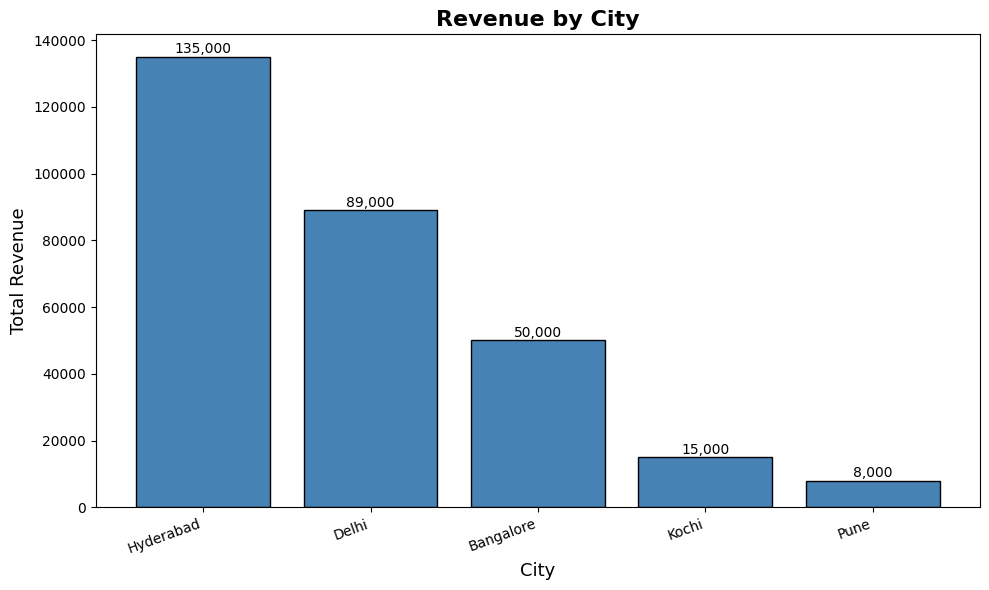

In [0]:
city_pd = revenue_by_city_df.toPandas()
plt.figure(figsize=(10, 6))
bars = plt.bar(city_pd["city"], city_pd["total_revenue"], color="steelblue", edgecolor="black")
plt.title("Revenue by City", fontsize=16, fontweight="bold")
plt.xlabel("City", fontsize=13)
plt.ylabel("Total Revenue", fontsize=13)
plt.xticks(rotation=20, ha="right")
for bar in bars:
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 200,
             f"{int(bar.get_height()):,}", ha="center", va="bottom", fontsize=10)
plt.tight_layout()
plt.show()

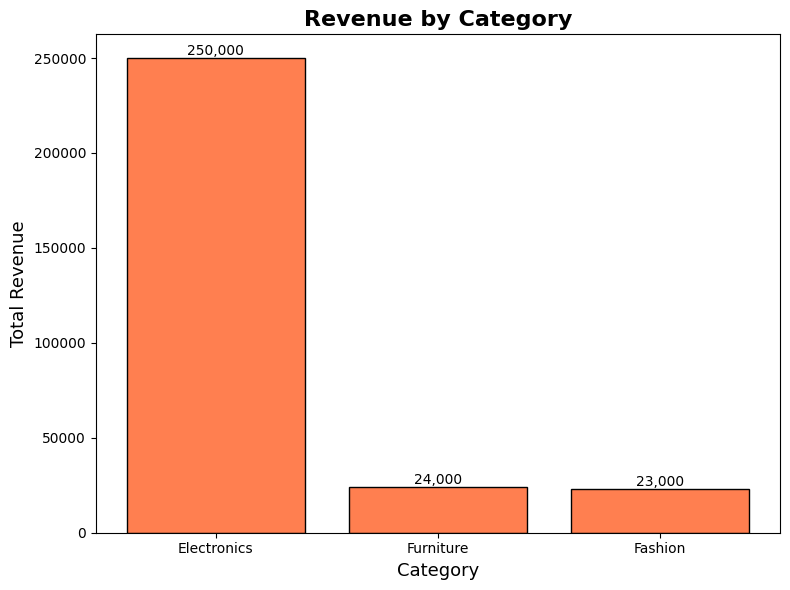

In [0]:
cat_pd = revenue_by_category_df.toPandas()
plt.figure(figsize=(8, 6))
bars = plt.bar(cat_pd["category"], cat_pd["total_revenue"], color="coral", edgecolor="black")
plt.title("Revenue by Category", fontsize=16, fontweight="bold")
plt.xlabel("Category", fontsize=13)
plt.ylabel("Total Revenue", fontsize=13)
for bar in bars:
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 200,
             f"{int(bar.get_height()):,}", ha="center", va="bottom", fontsize=10)
plt.tight_layout()
plt.show()

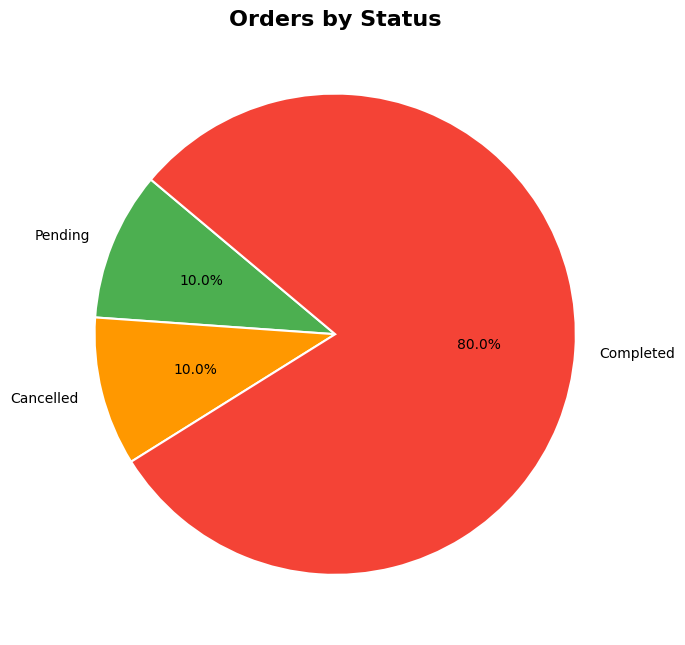

In [0]:
status_pd = orders_transformed_df.groupBy("status").count().toPandas()
colors = ["#4CAF50", "#FF9800", "#F44336"]
plt.figure(figsize=(7, 7))
plt.pie(
    status_pd["count"],
    labels=status_pd["status"],
    autopct="%1.1f%%",
    colors=colors,
    startangle=140,
    wedgeprops={"edgecolor": "white", "linewidth": 1.5}
)
plt.title("Orders by Status", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

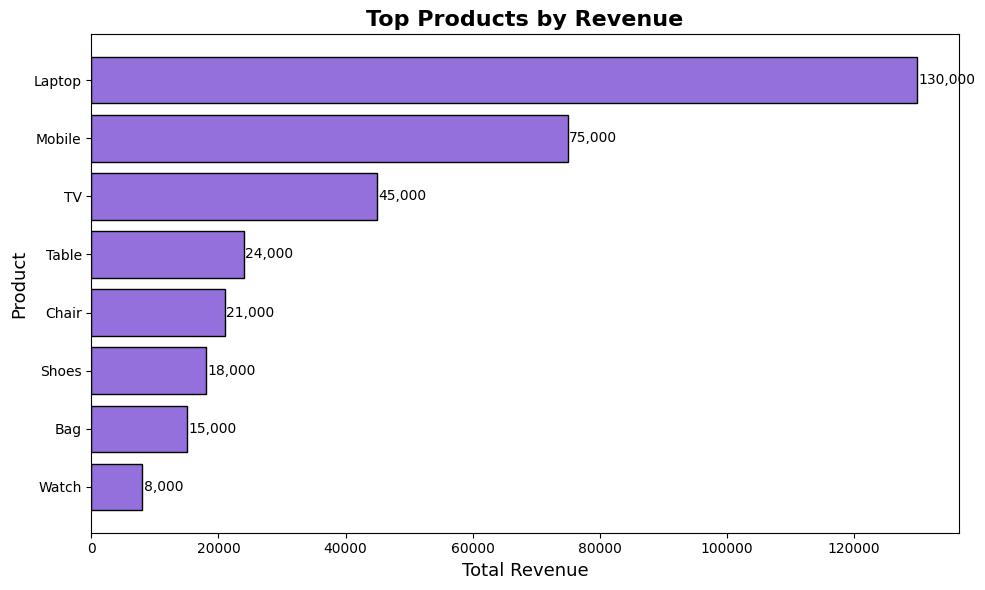

In [0]:
prod_pd = ranked_products_df.orderBy("revenue_rank").toPandas()
plt.figure(figsize=(10, 6))
bars = plt.barh(prod_pd["product_name"], prod_pd["total_revenue"], color="mediumpurple", edgecolor="black")
plt.title("Top Products by Revenue", fontsize=16, fontweight="bold")
plt.xlabel("Total Revenue", fontsize=13)
plt.ylabel("Product", fontsize=13)
for bar in bars:
    plt.text(bar.get_width() + 200, bar.get_y() + bar.get_height() / 2,
             f"{int(bar.get_width()):,}", va="center", fontsize=10)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

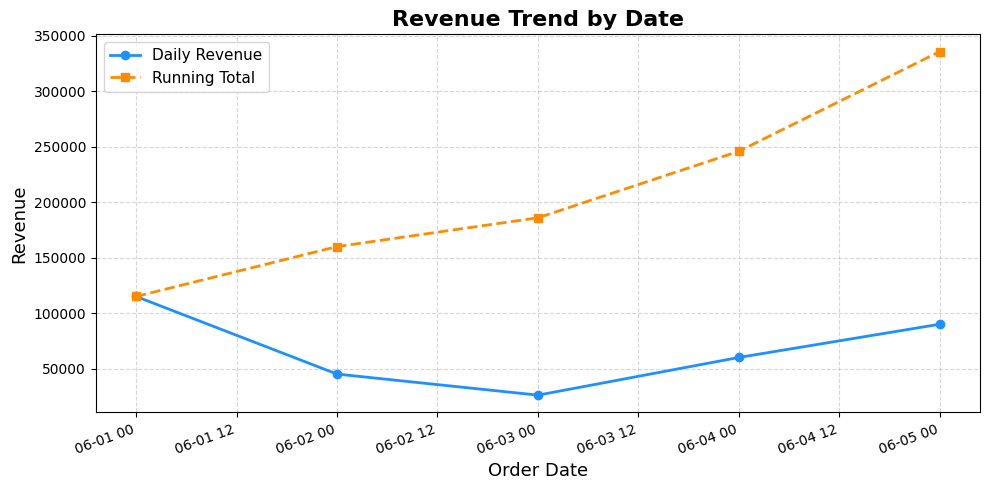

In [0]:
trend_pd = running_revenue_df.toPandas()
trend_pd["order_date"] = pd.to_datetime(trend_pd["order_date"])
plt.figure(figsize=(10, 5))
plt.plot(trend_pd["order_date"], trend_pd["daily_revenue"],
         marker="o", color="dodgerblue", linewidth=2, label="Daily Revenue")
plt.plot(trend_pd["order_date"], trend_pd["running_total_revenue"],
         marker="s", color="darkorange", linewidth=2, linestyle="--", label="Running Total")
plt.title("Revenue Trend by Date", fontsize=16, fontweight="bold")
plt.xlabel("Order Date", fontsize=13)
plt.ylabel("Revenue", fontsize=13)
plt.legend(fontsize=11)
plt.xticks(rotation=20, ha="right")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

In [0]:
spark.sql("""
    CREATE TABLE IF NOT EXISTS managed_orders
    USING DELTA
    AS SELECT * FROM silver_orders
""")
print("Managed Table created: managed_orders")

Managed Table created: managed_orders


In [0]:
orders_transformed_df.write \
    .format("delta") \
    .mode("overwrite") \
    .save("/Volumes/shashank_databricks123/default/retail/external_orders")
spark.sql("""
    CREATE OR REPLACE TABLE external_orders
    AS SELECT * FROM delta.`/Volumes/shashank_databricks123/default/retail/external_orders`
""")
print("External Table created: external_orders")

External Table created: external_orders


In [0]:
orders_transformed_df.createOrReplaceTempView("temp_orders_view")
print("Temporary View created: temp_orders_view")
spark.sql("SELECT * FROM temp_orders_view LIMIT 3").show()

Temporary View created: temp_orders_view
+----------+-----------+--------+----------+--------+---------+-------------+---------+-----------+-------------+------------+-----------+------------------+-------+-----------+----------------+
|product_id|customer_id|order_id|order_date|quantity|   status|customer_name|     city|      state|customer_type|product_name|   category|product_unit_price|revenue|order_month|customer_segment|
+----------+-----------+--------+----------+--------+---------+-------------+---------+-----------+-------------+------------+-----------+------------------+-------+-----------+----------------+
|      P101|       C101|   O1001|2026-06-01|       1|Completed| Rahul Sharma|Hyderabad|  Telangana|      Premium|      Laptop|Electronics|             65000|  65000|  June 2026|      High Value|
|      P102|       C102|   O1002|2026-06-01|       2|Completed|  Priya Reddy|Bangalore|  Karnataka|      Regular|      Mobile|Electronics|             25000|  50000|  June 2026|  

In [0]:
comparison = [
    ("Managed Table",
     "Available across all notebooks and sessions",
     "Remains until explicitly dropped"),

    ("External Table",
     "Available across all notebooks and sessions",
     "Metadata removed on drop; source data remains"),

    ("Temporary View",
     "Current notebook/session only",
     "Removed when the session ends"),

    ("Global Temporary View",
     "Available across Spark application sessions",
     "Removed when the Spark application stops")
]

columns = ["Object Type", "Scope", "Lifetime"]
comparison_df = spark.createDataFrame(comparison, columns)
display(comparison_df)

Object Type,Scope,Lifetime
Managed Table,Available across all notebooks and sessions,Remains until explicitly dropped
External Table,Available across all notebooks and sessions,Metadata removed on drop; source data remains
Temporary View,Current notebook/session only,Removed when the session ends
Global Temporary View,Available across Spark application sessions,Removed when the Spark application stops
